<a href="https://colab.research.google.com/github/brunokobi/computacao_natural/blob/main/EXC1_PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#🧮 Exercício Computacional 1 – Ajuste de uma curva usando algoritmos evolutivos(PSO)

# dependências e helpers

In [1]:
# Célula 1: imports e funções utilitárias
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from google.colab import files
import io


#upload dos arquivos (execute e suba seus .txt)

In [3]:
# Célula 2: faça upload dos arquivos x-data.txt e y-data.txt
print("Faça upload de x-data.txt e y-data.txt (cada um com uma coluna de valores).")
uploaded = files.upload()  # abre seletor de arquivos

# tenta ler os arquivos enviados
def load_column_from_uploaded(name_candidates):
    for name in name_candidates:
        if name in uploaded:
            content = uploaded[name].decode('utf-8')
            arr = np.loadtxt(io.StringIO(content))
            return arr
    return None

x = load_column_from_uploaded(["x-data.txt", "x_data.txt", "x.txt", "xdata.txt"])
y = load_column_from_uploaded(["y-data.txt", "y_data.txt", "y.txt", "ydata.txt"])

if x is None or y is None:
    raise FileNotFoundError("Não encontrou x-data.txt ou y-data.txt no upload. Verifique os nomes.")

if x.shape[0] != y.shape[0]:
    raise ValueError("x e y devem ter o mesmo número de pontos (linhas).")

print(f"Dados carregados: {x.shape[0]} pontos.")


Faça upload de x-data.txt e y-data.txt (cada um com uma coluna de valores).


Saving x_data.txt to x_data.txt
Saving y_data.txt to y_data.txt
Dados carregados: 101 pontos.


#definição do modelo e função custo (SSE)

In [4]:
# Célula 3: modelo polinomial e SSE
def model(params, x):
    # params = [a, b, c]
    a, b, c = params
    return a * x**2 + b * x + c

def sse(params, x, y):
    pred = model(params, x)
    err = y - pred
    return np.sum(err**2)


#implementação PSO (configurável)

In [5]:
# Célula 4: PSO simples
import math
import random

def pso_optimize(cost_func, x, y,
                 bounds,            # [(amin,amax),(bmin,bmax),(cmin,cmax)]
                 swarmsize=50,
                 maxiter=200,
                 w=0.7, c1=1.5, c2=1.5,
                 seed=None,
                 verbose=False):
    """
    Retorna: best_params, best_cost, history_cost (list of best cost per iter)
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    dim = len(bounds)
    # inicializa partículas
    pos = np.zeros((swarmsize, dim))
    vel = np.zeros((swarmsize, dim))
    pbest_pos = np.zeros((swarmsize, dim))
    pbest_cost = np.full(swarmsize, np.inf)

    # inicializa posições aleatórias dentro dos limites
    for d in range(dim):
        low, high = bounds[d]
        pos[:, d] = np.random.uniform(low, high, swarmsize)
        vel[:, d] = np.random.uniform(-(high-low), (high-low), swarmsize) * 0.1

    # avalia pbest e gbest
    for i in range(swarmsize):
        cost = cost_func(pos[i], x, y)
        pbest_pos[i] = pos[i].copy()
        pbest_cost[i] = cost

    gbest_idx = np.argmin(pbest_cost)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_cost = pbest_cost[gbest_idx]

    history = []
    for it in range(maxiter):
        for i in range(swarmsize):
            r1 = np.random.rand(dim)
            r2 = np.random.rand(dim)
            # atualização velocidade
            vel[i] = w * vel[i] + c1 * r1 * (pbest_pos[i] - pos[i]) + c2 * r2 * (gbest_pos - pos[i])
            pos[i] = pos[i] + vel[i]
            # aplica limites de posição (clamp)
            for d in range(dim):
                low, high = bounds[d]
                if pos[i, d] < low:
                    pos[i, d] = low
                    vel[i, d] = 0
                if pos[i, d] > high:
                    pos[i, d] = high
                    vel[i, d] = 0

            cost = cost_func(pos[i], x, y)
            # atualiza pbest
            if cost < pbest_cost[i]:
                pbest_cost[i] = cost
                pbest_pos[i] = pos[i].copy()
                # atualiza gbest
                if cost < gbest_cost:
                    gbest_cost = cost
                    gbest_pos = pos[i].copy()

        history.append(gbest_cost)
        if verbose and (it % (maxiter//10 if maxiter>=10 else 1) == 0):
            print(f"Iter {it}/{maxiter} - best SSE: {gbest_cost:.6g}")

    return gbest_pos, float(gbest_cost), history


#parâmetros, execução de 10 runs e estatísticas

In [6]:
# Célula 5: parâmetros do problema e múltiplas execuções
bounds = [(-5, 5), (-5, 5), (-5, 5)]  # para a, b, c

# PSO hyperparams (você pode ajustar)
swarmsize = 60
maxiter = 300
w = 0.7
c1 = 1.5
c2 = 1.5

n_runs = 10
results = []
all_histories = []

start_all = time.time()
for run in range(n_runs):
    seed = int(time.time()*1000) % 2**32 + run  # semente variável por run
    best_params, best_cost, history = pso_optimize(
        sse, x, y,
        bounds=bounds,
        swarmsize=swarmsize,
        maxiter=maxiter,
        w=w, c1=c1, c2=c2,
        seed=seed,
        verbose=False
    )
    results.append((best_params, best_cost, seed))
    all_histories.append(history)
    print(f"Run {run+1}/{n_runs} -> SSE: {best_cost:.6g}, params: a={best_params[0]:.6g}, b={best_params[1]:.6g}, c={best_params[2]:.6g}")

end_all = time.time()
print(f"\nTempo total: {end_all - start_all:.2f} s")


Run 1/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 2/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 3/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 4/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 5/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 6/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 7/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 8/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 9/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095
Run 10/10 -> SSE: 8.31524e-08, params: a=-0.294202, b=1.02311, c=0.498095

Tempo total: 7.14 s


#estatísticas (melhor, média, desv. padrão) e salvar CSV

In [7]:
# Célula 6: estatísticas e salvar resultados
costs = np.array([r[1] for r in results])
best_idx = np.argmin(costs)
best_params, best_cost, best_seed = results[best_idx]

print("=== Estatísticas (SSE) ===")
print(f"Melhor SSE (entre {n_runs} runs): {best_cost:.6g} (run {best_idx+1})")
print(f"Média SSE: {costs.mean():.6g}")
print(f"Desvio padrão SSE: {costs.std(ddof=0):.6g}")

# salva resultados em CSV
df = pd.DataFrame({
    "run": np.arange(1, n_runs+1),
    "SSE": costs,
    "a": [r[0][0] for r in results],
    "b": [r[0][1] for r in results],
    "c": [r[0][2] for r in results],
    "seed": [r[2] for r in results]
})
csv_bytes = df.to_csv(index=False).encode('utf-8')
open('pso_results.csv','wb').write(csv_bytes)
print("\nResultados salvos em pso_results.csv")
files.download('pso_results.csv')


=== Estatísticas (SSE) ===
Melhor SSE (entre 10 runs): 8.31524e-08 (run 2)
Média SSE: 8.31524e-08
Desvio padrão SSE: 1.306e-17

Resultados salvos em pso_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#plot: dados vs curva ajustada (melhor run)

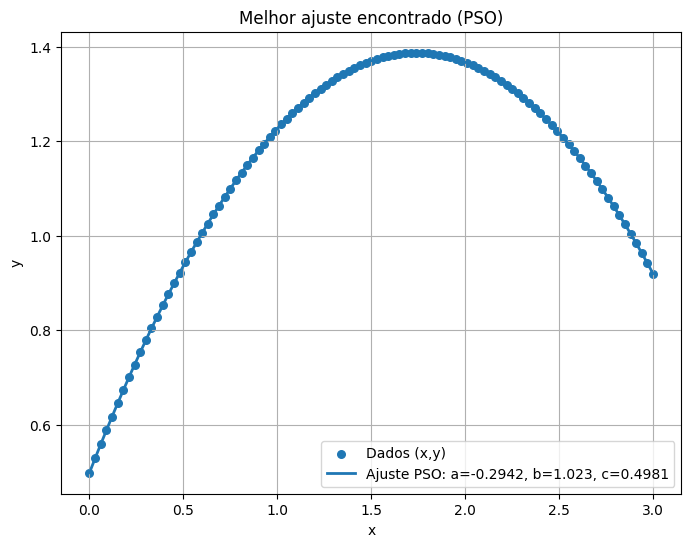

In [8]:
# Célula 7: plot do melhor ajuste
best_params = results[best_idx][0]
xx = np.linspace(np.min(x), np.max(x), 400)
yy = model(best_params, xx)

plt.figure(figsize=(8,6))
plt.scatter(x, y, label='Dados (x,y)', s=30)
plt.plot(xx, yy, label=f'Ajuste PSO: a={best_params[0]:.4g}, b={best_params[1]:.4g}, c={best_params[2]:.4g}', linewidth=2)
plt.title('Melhor ajuste encontrado (PSO)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


#plot: convergência (melhor histórico e médiana)

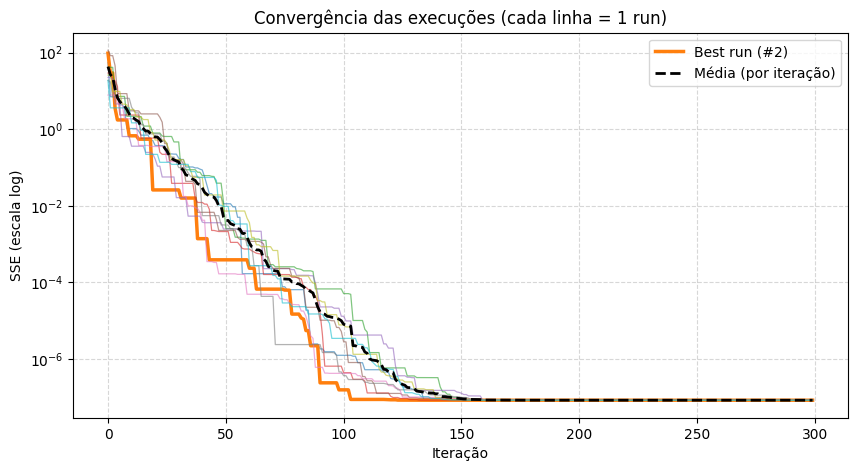

In [9]:
# Célula 8: plots de convergência
plt.figure(figsize=(10,5))
for i, hist in enumerate(all_histories):
    if i == best_idx:
        plt.plot(hist, lw=2.5, label=f'Best run (#{i+1})')
    else:
        plt.plot(hist, lw=0.9, alpha=0.6)
# linha da média por iteração (padronizar comprimentos)
minlen = min(len(h) for h in all_histories)
hist_trimmed = np.array([h[:minlen] for h in all_histories])
mean_hist = hist_trimmed.mean(axis=0)
plt.plot(mean_hist, 'k--', lw=2, label='Média (por iteração)')
plt.yscale('log')  # SSE costuma decrescer muito — escala log facilita visualização
plt.xlabel('Iteração')
plt.ylabel('SSE (escala log)')
plt.title('Convergência das execuções (cada linha = 1 run)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()
